# Description

The project develops a supervised machine‑learning model to detect cyberattacks using the Cyber Attack Detection dataset, which contains network‑flow statistics and labeled traffic behaviors. The goal is to preprocess the data, explore its structure visually, and compare multiple classification algorithms to identify the most accurate model. The final model is then applied to the unseen test set to generate predicted attack labels for submission.

## Goal
Use the Cyber_Attack_Detection_train.csv dataset to build a classification model that predicts the network traffic Label (attack type) from flow‑based features.

# PART I - COVERING WRITING REPORT

# SECTION I:

## Setup

In [1]:
# Common imports
import numpy as np
import pandas as pd

np.random.seed(55)

# 1. Get the Data

In [2]:
# Import the data set:
df = pd.read_csv("Cyber_Attack_Detection_train.csv")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,47855867,13,12,1744,7861,424,0,134.153846,201.127591,...,20.0,2.758619e+06,4.714091e+06,8201982.0,36851.0,1.000000e+07,651.178419,10000000.0,9999427.0,BENIGN
1,53,48791,2,2,64,238,32,32,32.000000,0.000000,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
2,443,32194,1,2,0,0,0,0,0.000000,0.000000,...,32.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
3,57324,459,2,0,12,0,6,6,6.000000,0.000000,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
4,443,66040511,15,16,845,6488,461,0,56.333333,124.801366,...,20.0,2.221813e+05,4.133482e+05,1065924.0,52850.0,9.995801e+06,10852.552270,10000000.0,9973667.0,BENIGN


### 1.1. Clean Column names

In [3]:
df.columns = df.columns.str.strip()
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,47855867,13,12,1744,7861,424,0,134.153846,201.127591,...,20.0,2.758619e+06,4.714091e+06,8201982.0,36851.0,1.000000e+07,651.178419,10000000.0,9999427.0,BENIGN
1,53,48791,2,2,64,238,32,32,32.000000,0.000000,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
2,443,32194,1,2,0,0,0,0,0.000000,0.000000,...,32.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
3,57324,459,2,0,12,0,6,6,6.000000,0.000000,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
4,443,66040511,15,16,845,6488,461,0,56.333333,124.801366,...,20.0,2.221813e+05,4.133482e+05,1065924.0,52850.0,9.995801e+06,10852.552270,10000000.0,9973667.0,BENIGN


### 1.2. Drop Duplicate columns

In [4]:
cols_to_drop = [
    "Fwd Header Length.1",
    "Bwd PSH Flags", "Fwd URG Flags", "Bwd URG Flags", "CWE Flag Count",
    "Fwd Avg Bytes/Bulk", "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk", "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate",
    "Subflow Fwd Packets", "Subflow Bwd Packets",
    "Subflow Fwd Bytes", "Subflow Bwd Bytes",
    "Flow IAT Min", "Fwd IAT Min",
    "Init_Win_bytes_forward", "Init_Win_bytes_backward"
]

df = df.drop(
    columns=[c for c in cols_to_drop if c in df.columns]
)

# SECTION II:

## 2. Data Visualization

### 2.1. Convert a sample  to pandas

In [5]:
pdf = df.sample(frac=0.10, random_state=55)
pdf.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
9823,80,1561901,2,0,0,0,0,0,0.000000,0.000000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
370670,55838,60,1,1,0,0,0,0,0.000000,0.000000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
15842,80,85002182,4,7,314,11595,308,0,78.500000,153.026142,...,20.0,0.0,0.0,0.0,0.0,84900000.0,0.0,84900000.0,84900000.0,DoS Hulk
167660,53,210,2,2,86,228,43,43,43.000000,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
61219,80,98507994,7,4,382,11595,376,0,54.571429,141.754315,...,20.0,1030.0,0.0,1030.0,1030.0,98500000.0,0.0,98500000.0,98500000.0,DoS Hulk


### 2.2. Identify numeric columns

In [6]:
numeric_cols = pdf.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'URG Flag Count',
 'ECE Flag Count',
 'Down/Up Ratio',
 'Average Packet Size',
 'Avg Fwd S

### 2.3. Helper functions

In [7]:
from scipy.stats import shapiro, trim_mean

def mode_safe(x):
    return x.mode().iloc[0] if not x.mode().empty else np.nan

def outlier_count(x):
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((x < lower) | (x > upper)).sum()

def mad_safe(x):
    return np.mean(np.abs(x - np.mean(x)))

### 2.4. Summary statisics table

In [8]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

# ── Sheet 1: df.describe() ──
desc = df[numeric_cols].describe().T
desc.index.name = "Feature"

# ── Sheet 2: Full summary ──
summary = pd.DataFrame(index=numeric_cols)
summary["Type"] = df[numeric_cols].dtypes.astype(str)
summary["Min"] = df[numeric_cols].min()
summary["Max"] = df[numeric_cols].max()
summary["Range"] = summary["Min"].astype(str) + " - " + summary["Max"].astype(str)
summary["Median"] = df[numeric_cols].median()
summary["Mode"] = df[numeric_cols].apply(mode_safe)
summary["SD"] = df[numeric_cols].std()
summary["Variance"] = df[numeric_cols].var()
summary["IQR"] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
summary["MAD"] = df[numeric_cols].apply(mad_safe)
summary["TrimmedMean"] = df[numeric_cols].apply(lambda x: trim_mean(x, 0.1))
summary["CV"] = summary["SD"] / summary["Median"]
summary["UniqueVals"] = df[numeric_cols].nunique()
summary["Outliers"] = df[numeric_cols].apply(outlier_count)
summary["ShapiroP"] = df[numeric_cols].apply(
    lambda x: shapiro(x.sample(500, replace=False))[1] if (len(x) > 500 and x.var() > 0) else (shapiro(x)[1] if x.var() > 0 else np.nan)
)
summary["P10"] = df[numeric_cols].quantile(0.10)
summary["P90"] = df[numeric_cols].quantile(0.90)
summary["RangeRatio"] = summary["Max"] / summary["Min"].replace(0, np.nan)
summary["NormMean"] = summary["Median"] / summary["Max"]
summary["Negatives"] = (df[numeric_cols] < 0).sum()
summary = summary.round(4)
summary.index.name = "Feature"

# ── Write to Excel with formatting ──
wb = Workbook()

header_font = Font(bold=True, color="FFFFFF", name="Arial", size=11)
header_fill = PatternFill("solid", fgColor="4472C4")
header_align = Alignment(horizontal="center", vertical="center", wrap_text=True)
cell_font = Font(name="Arial", size=10)
thin_border = Border(
    left=Side(style="thin"), right=Side(style="thin"),
    top=Side(style="thin"), bottom=Side(style="thin")
)

def write_sheet(ws, df_in):
    for r_idx, row in enumerate(dataframe_to_rows(df_in.reset_index(), index=False, header=True), 1):
        for c_idx, val in enumerate(row, 1):
            cell = ws.cell(row=r_idx, column=c_idx, value=val)
            cell.border = thin_border
            if r_idx == 1:
                cell.font = header_font
                cell.fill = header_fill
                cell.alignment = header_align
            else:
                cell.font = cell_font
                cell.alignment = Alignment(horizontal="right")
                if c_idx == 1:
                    cell.alignment = Alignment(horizontal="left")
    # Auto-fit columns
    for col in ws.columns:
        max_len = max(len(str(c.value or "")) for c in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 3, 25)
    ws.auto_filter.ref = ws.dimensions
    ws.freeze_panes = "B2"

# Sheet 1
ws1 = wb.active
ws1.title = "Descriptive Statistics"
write_sheet(ws1, desc)

# Sheet 2
ws2 = wb.create_sheet("Full Summary")
write_sheet(ws2, summary)

wb.save("summary_statistics.xlsx")
print("Saved: summary_statistics.xlsx — 2 sheets (Descriptive Statistics + Full Summary)")
summary

c:\Users\kakum\OneDrive\Desktop\apdi\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


Saved: summary_statistics.xlsx — 2 sheets (Descriptive Statistics + Full Summary)


,Type,Min,Max,Range,Median,Mode,SD,Variance,IQR,MAD,TrimmedMean,CV,UniqueVals,Outliers,ShapiroP,P10,P90,RangeRatio,NormMean,Negatives
Feature,,,,,,,,,,,,,,,,,,,,
Destination Port,int64,0.000000e+00,6.542700e+04,0.0 - 65427.0,80.0000,5.300000e+01,1.803328e+04,3.251991e+08,3.900000e+02,1.242644e+04,2.427578e+03,2.254160e+02,28788,67153,0.0,53.0000,4.986000e+04,NaN,0.0012,0
Flow Duration,int64,-1.000000e+00,1.200000e+08,-1.0 - 119999977.0,46470.5000,3.000000e+00,3.698186e+07,1.367658e+15,5.512978e+06,2.809663e+07,9.475876e+06,7.958136e+02,211087,87531,0.0,36.0000,9.831514e+07,-1.200000e+08,0.0004,12
Total Fwd Packets,int64,1.000000e+00,2.064460e+05,1.0 - 206446.0,2.0000,2.000000e+00,8.556967e+02,7.322169e+05,4.000000e+00,1.402970e+01,3.411800e+00,4.278484e+02,602,44094,0.0,1.0000,1.300000e+01,2.064460e+05,0.0000,0
Total Backward Packets,int64,0.000000e+00,2.760720e+05,0.0 - 276072.0,2.0000,2.000000e+00,1.149463e+03,1.321266e+06,4.000000e+00,1.824080e+01,2.621100e+00,5.747317e+02,764,42734,0.0,0.0000,1.100000e+01,NaN,0.0000,0
Total Length of Fwd Packets,int64,0.000000e+00,2.428415e+06,0.0 - 2428415.0,72.0000,0.000000e+00,6.805919e+03,4.632053e+07,3.350000e+02,7.538405e+02,1.579341e+02,9.452670e+01,8099,47508,0.0,0.0000,8.870000e+02,NaN,0.0000,0
Total Length of Bwd Packets,int64,0.000000e+00,6.270000e+08,0.0 - 627000000.0,154.0000,0.000000e+00,2.575067e+06,6.630973e+12,1.088000e+03,3.519254e+04,1.309410e+03,1.672122e+04,20735,99391,0.0,0.0000,1.159500e+04,NaN,0.0000,0
Fwd Packet Length Max,int64,0.000000e+00,2.482000e+04,0.0 - 24820.0,42.0000,0.000000e+00,5.361675e+02,2.874755e+05,2.870000e+02,2.430430e+02,1.044142e+02,1.276590e+01,3405,19538,0.0,0.0000,4.360000e+02,NaN,0.0017,0
Fwd Packet Length Min,int64,0.000000e+00,1.983000e+03,0.0 - 1983.0,0.0000,0.000000e+00,4.279590e+01,1.831490e+03,3.800000e+01,2.161230e+01,1.391830e+01,inf,213,1552,0.0,0.0000,4.800000e+01,NaN,0.0000,0
Fwd Packet Length Mean,float64,0.000000e+00,4.672000e+03,0.0 - 4672.0,38.5000,0.000000e+00,1.343310e+02,1.804483e+04,4.700000e+01,4.403430e+01,3.497530e+01,3.489100e+00,26752,25859,0.0,0.0000,8.871000e+01,NaN,0.0082,0


### 2.5. Class Distribution

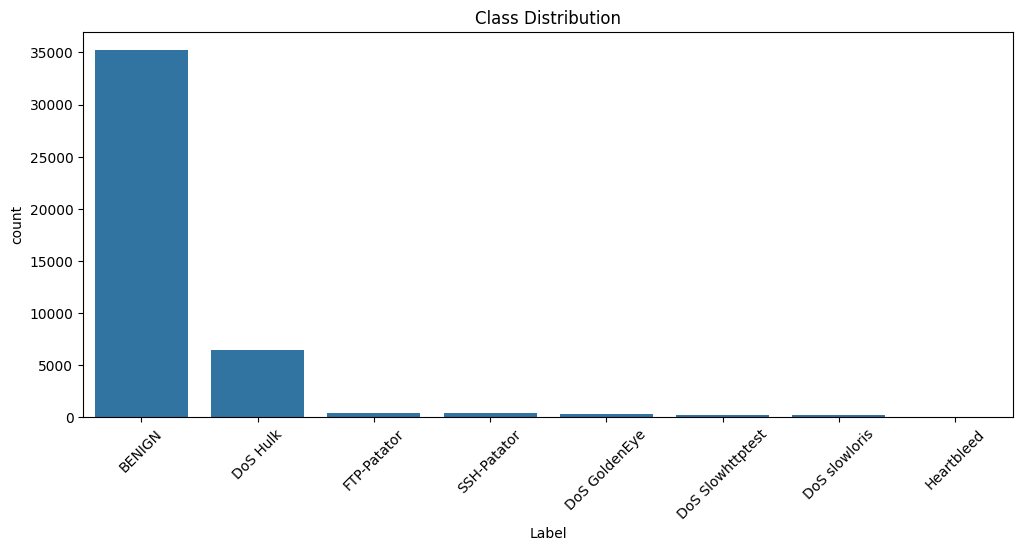

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.countplot(data=pdf, x="Label", order=pdf["Label"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

### 2.6. Histograms

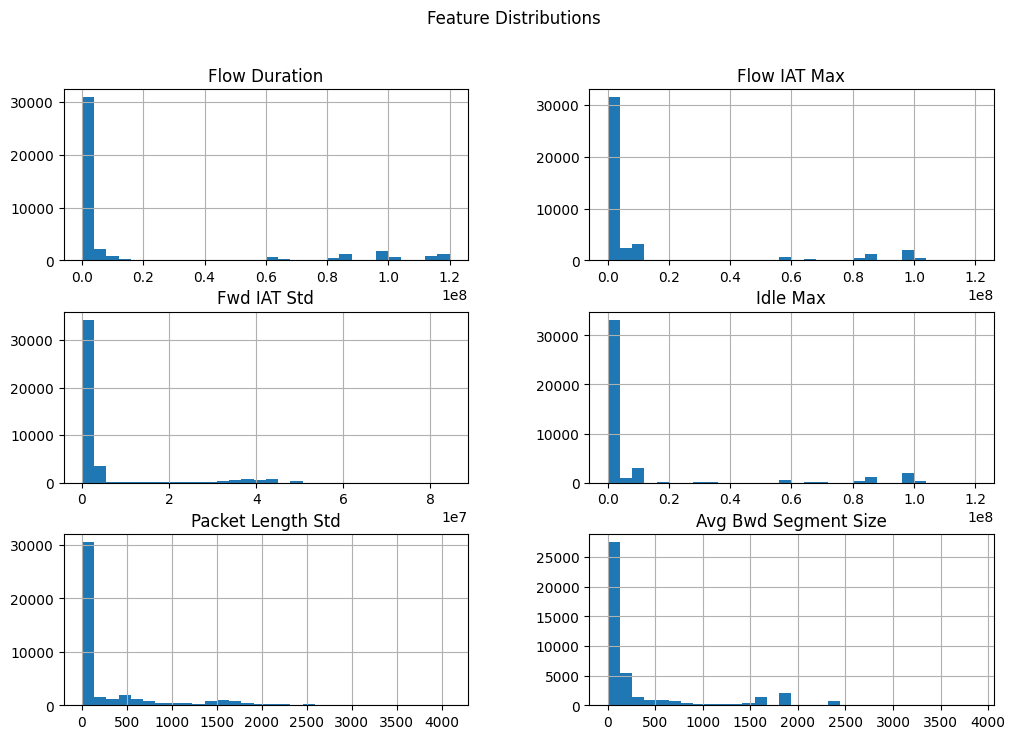

In [10]:
numeric_sample = [
    "Flow Duration",
    "Flow IAT Max",
    "Fwd IAT Std",
    "Idle Max",
    "Packet Length Std",
    "Avg Bwd Segment Size"
]

pdf[numeric_sample].hist(figsize=(12,8), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

### 2.7. Correlation heatmap

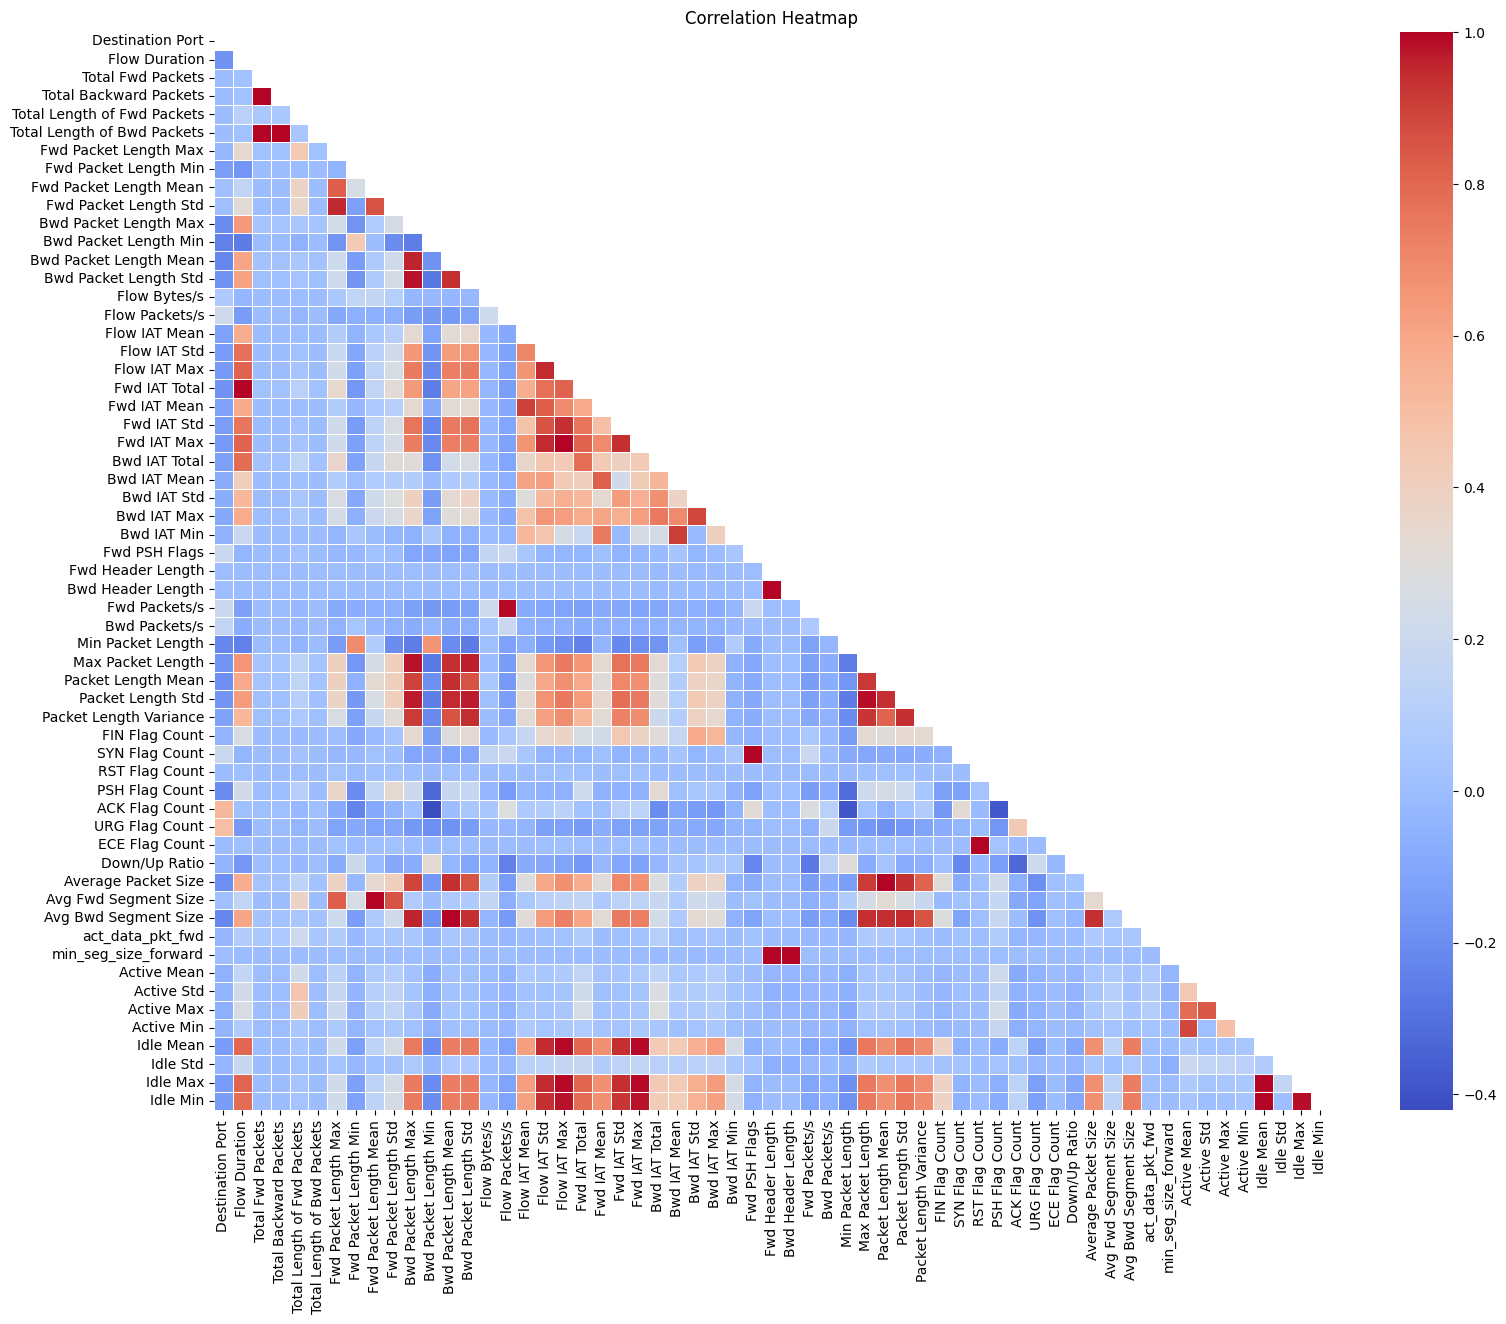

In [11]:
corr = pdf[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18,14))
sns.heatmap(corr, mask=mask, cmap="coolwarm", linewidths=.5)
plt.title("Correlation Heatmap")
plt.show()

### 2.8. Boxplots

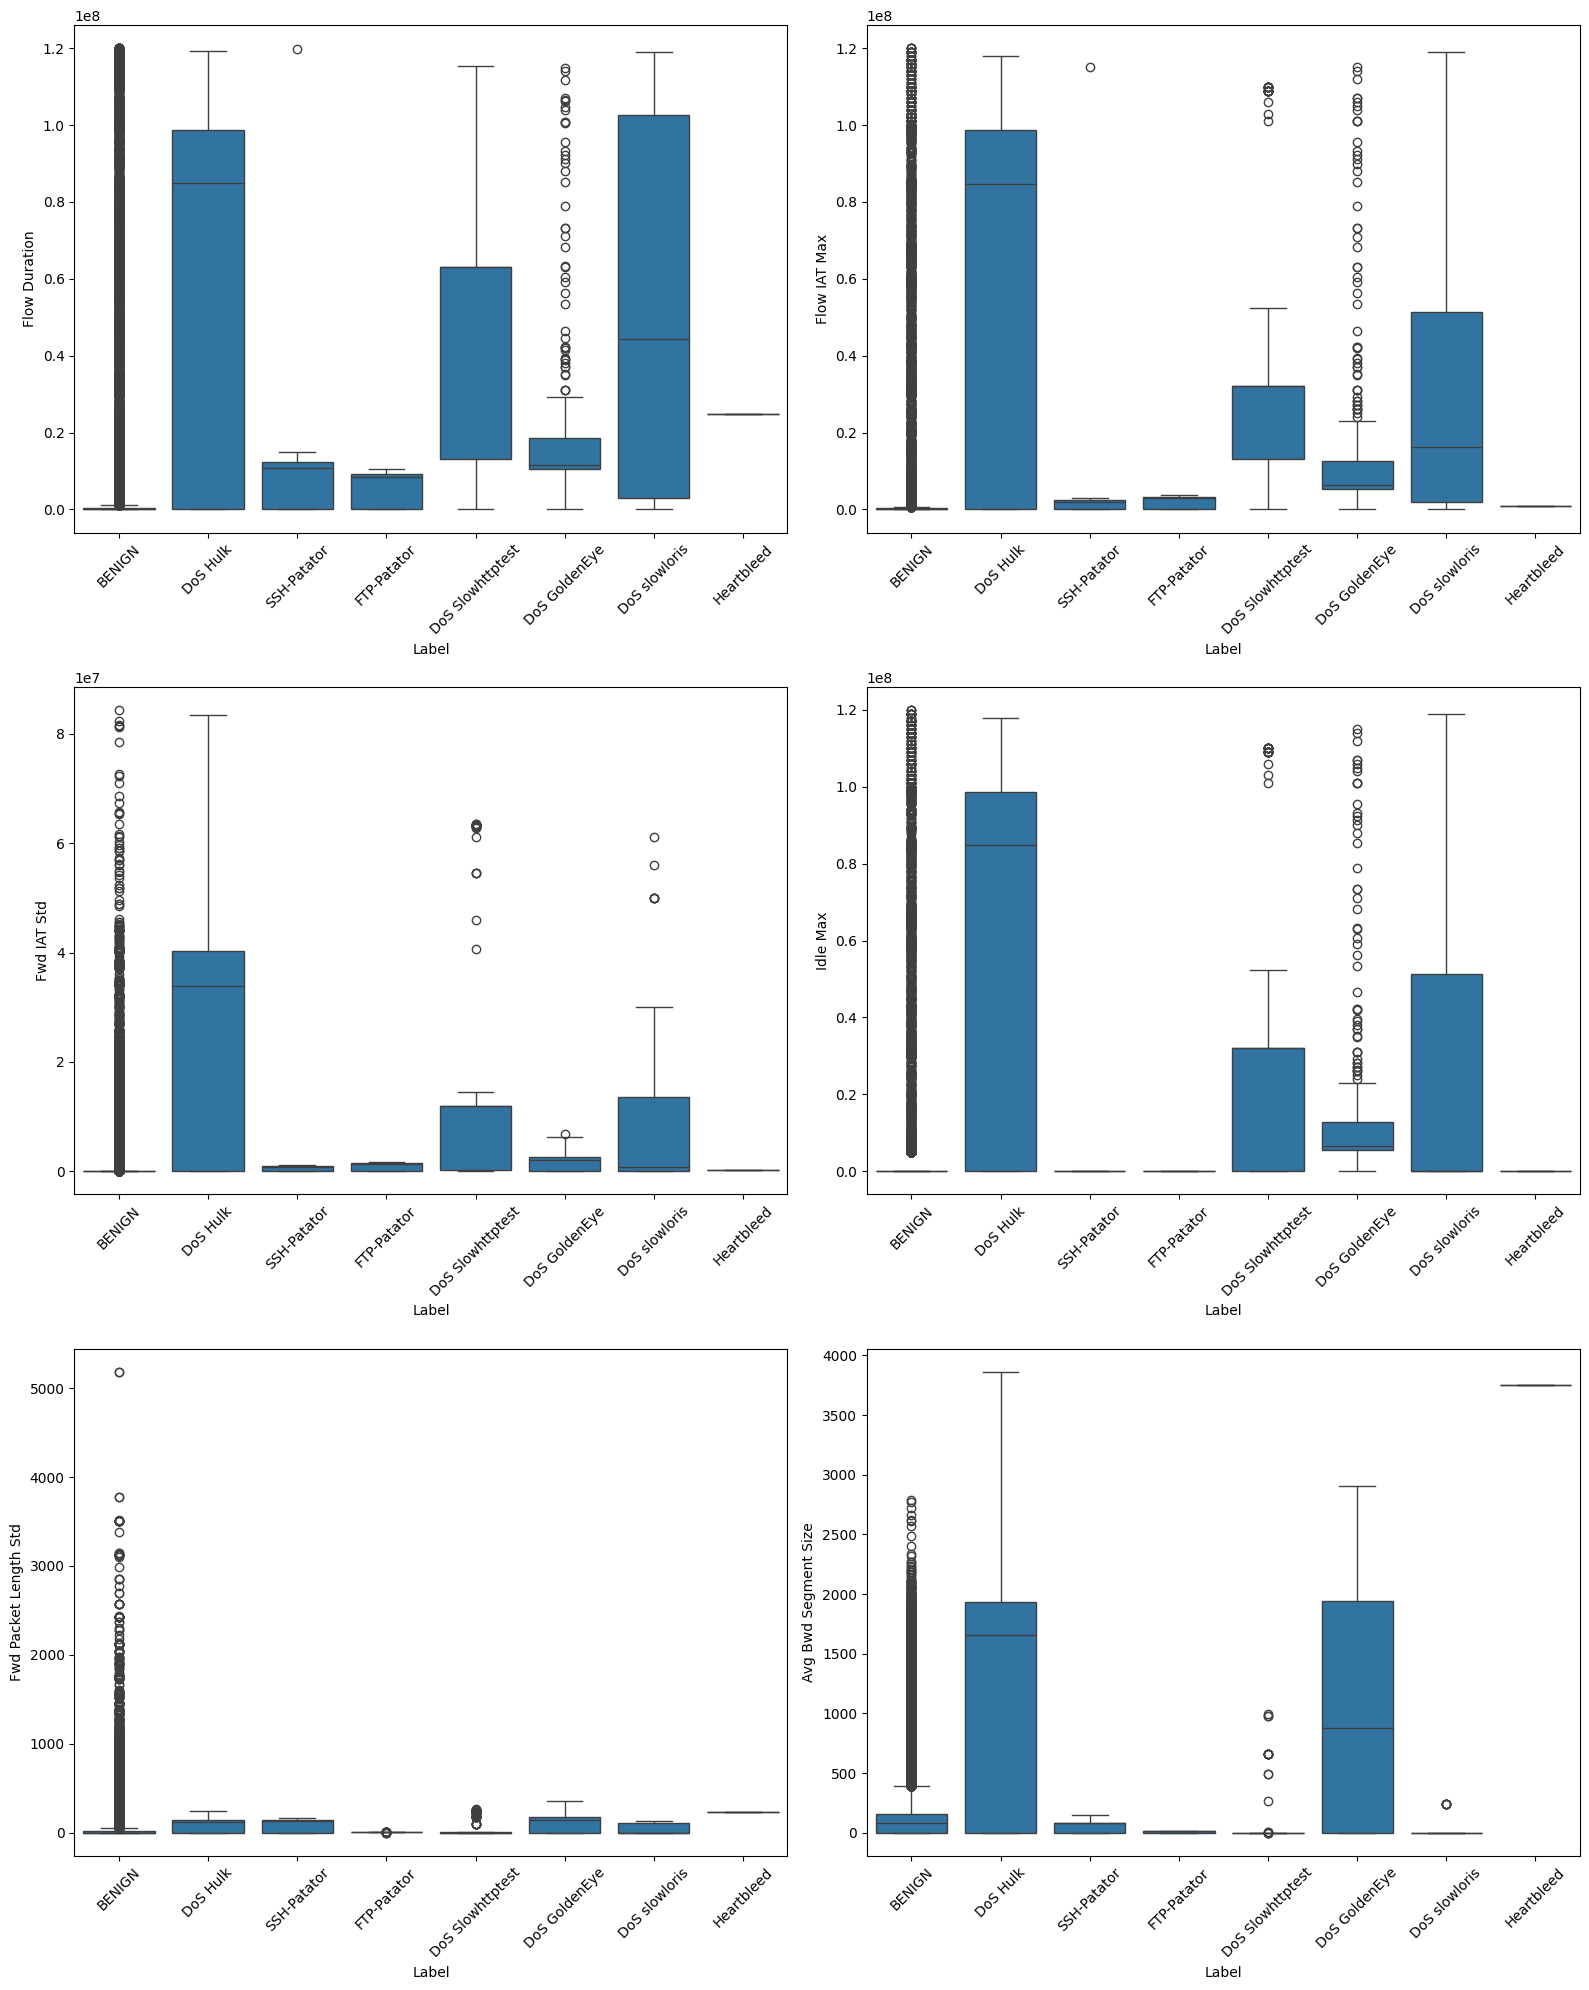

In [12]:
boxplot_features = [
    "Flow Duration",
    "Flow IAT Max",
    "Fwd IAT Std",
    "Idle Max",
    "Fwd Packet Length Std",
    "Avg Bwd Segment Size"
]

plt.figure(figsize=(16,20))
for i, col in enumerate(boxplot_features, 1):
    plt.subplot(3,2,i)
    sns.boxplot(data=pdf, x="Label", y=col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# SECTION III:

## Preprocessing for sckit-learn

### 3.1. Clean numeric columns

In [13]:
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df = df.dropna()


### 3.2. Encode label

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label_index"] = le.fit_transform(df["Label"])

### 3.3. Train / Test Split

In [15]:
from sklearn.model_selection import train_test_split

X = df[numeric_cols]
y = df["label_index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=55
)

In [16]:
from sklearn.model_selection import train_test_split

# Sample a smaller subset from the training data for "heavy" models
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=100000,      
    stratify=y_train,
    random_state=55
)

# SECTION IV:

## 4. Trained Models

### 4.0. Sampling & Scaling

We sample 50,000 rows from the training set (stratified) to keep runtimes manageable while preserving class proportions.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time

# ── Stratified sample: 50k rows ──
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train,
    train_size=50_000,
    stratify=y_train,
    random_state=55
)

print(f'Training sample: {X_sample.shape[0]:,} rows')
print(f'Test set:        {X_test.shape[0]:,} rows')

# ── Scale ──
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)
X_test_scaled   = scaler.transform(X_test)

Training sample: 50,000 rows
Test set:        128,776 rows


### 4.1. Random Forest Classifier

In [18]:
from sklearn.ensemble import RandomForestClassifier

start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=55
)

rf.fit(X_sample, y_sample)          # tree — no scaling needed
pred_rf = rf.predict(X_test)

f1_rf = f1_score(y_test, pred_rf, average='weighted')
print(f'Random Forest  Weighted F1: {f1_rf:.4f}  |  Time: {time.time()-start:.1f}s')
print(classification_report(y_test, pred_rf))

Random Forest  Weighted F1: 0.9969  |  Time: 1.5s
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    105491
           1       1.00      0.92      0.96       911
           2       1.00      0.99      0.99     19296
           3       0.99      0.93      0.96       418
           4       1.00      0.91      0.95       446
           5       1.00      1.00      1.00      1263
           7       0.99      0.97      0.98       951

    accuracy                           1.00    128776
   macro avg       1.00      0.96      0.98    128776
weighted avg       1.00      1.00      1.00    128776



### 4.2. Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression

start = time.time()

lr = LogisticRegression(
    max_iter=3000,
    solver='saga',
##    multi_class='multinomial',
    tol=0.01,
    n_jobs=-1,
    random_state=55
)

lr.fit(X_sample_scaled, y_sample)   # linear — needs scaling
pred_lr = lr.predict(X_test_scaled)

f1_lr = f1_score(y_test, pred_lr, average='weighted')
print(f'Logistic Regression  Weighted F1: {f1_lr:.4f}  |  Time: {time.time()-start:.1f}s')
print(classification_report(y_test, pred_lr))

c:\Users\kakum\OneDrive\Desktop\apdi\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression  Weighted F1: 0.9356  |  Time: 4.6s
              precision    recall  f1-score   support

           0       0.95      0.99      0.97    105491
           1       0.86      0.16      0.27       911
           2       0.93      0.88      0.90     19296
           3       0.77      0.71      0.74       418
           4       0.48      0.13      0.20       446
           5       0.00      0.00      0.00      1263
           7       0.00      0.00      0.00       951

    accuracy                           0.95    128776
   macro avg       0.57      0.41      0.44    128776
weighted avg       0.93      0.95      0.94    128776



### 4.3. Support Vector Machine (Linear SVM)

In [20]:
from sklearn.svm import LinearSVC

start = time.time()

svm = LinearSVC(
    C=1.0,
    max_iter=3000,
    dual=False,
    loss='squared_hinge',
    random_state=55
)

svm.fit(X_sample_scaled, y_sample)  # linear — needs scaling
pred_svm = svm.predict(X_test_scaled)

f1_svm = f1_score(y_test, pred_svm, average='weighted')
print(f'SVM  Weighted F1: {f1_svm:.4f}  |  Time: {time.time()-start:.1f}s')
print(classification_report(y_test, pred_svm))

SVM  Weighted F1: 0.9869  |  Time: 87.2s
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    105491
           1       0.97      0.92      0.94       911
           2       0.97      0.99      0.98     19296
           3       0.84      0.83      0.83       418
           4       0.96      0.83      0.89       446
           5       0.93      1.00      0.96      1263
           7       0.98      0.52      0.68       951

    accuracy                           0.99    128776
   macro avg       0.95      0.87      0.90    128776
weighted avg       0.99      0.99      0.99    128776



### 4.4. K-Nearest Neighbors (KNN)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

start = time.time()

knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    algorithm='ball_tree',
    n_jobs=-1
)

knn.fit(X_sample_scaled, y_sample)  # distance — needs scaling
pred_knn = knn.predict(X_test_scaled)

f1_knn = f1_score(y_test, pred_knn, average='weighted')
print(f'KNN  Weighted F1: {f1_knn:.4f}  |  Time: {time.time()-start:.1f}s')
print(classification_report(y_test, pred_knn))

KNN  Weighted F1: 0.9972  |  Time: 105.5s
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    105491
           1       0.95      0.98      0.96       911
           2       1.00      0.99      1.00     19296
           3       0.93      0.95      0.94       418
           4       0.96      0.95      0.95       446
           5       1.00      1.00      1.00      1263
           7       0.98      0.98      0.98       951

    accuracy                           1.00    128776
   macro avg       0.97      0.98      0.98    128776
weighted avg       1.00      1.00      1.00    128776



### 4.5. Gradient Boosting Classifier

In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier

start = time.time()

gb = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=55
)

gb.fit(X_sample, y_sample)          # tree — no scaling needed
pred_gb = gb.predict(X_test)

f1_gb = f1_score(y_test, pred_gb, average='weighted')
print(f'Gradient Boosting  Weighted F1: {f1_gb:.4f}  |  Time: {time.time()-start:.1f}s')
print(classification_report(y_test, pred_gb))

Gradient Boosting  Weighted F1: 0.9892  |  Time: 3.6s
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    105491
           1       0.74      0.77      0.75       911
           2       0.99      0.99      0.99     19296
           3       0.40      0.67      0.50       418
           4       0.80      0.59      0.68       446
           5       1.00      1.00      1.00      1263
           7       0.99      0.98      0.98       951

    accuracy                           0.99    128776
   macro avg       0.84      0.86      0.84    128776
weighted avg       0.99      0.99      0.99    128776



### 4.6. Naive Bayes

In [23]:
from sklearn.naive_bayes import GaussianNB

start = time.time()

nb = GaussianNB()

nb.fit(X_sample_scaled, y_sample)   # benefits from scaling
pred_nb = nb.predict(X_test_scaled)

f1_nb = f1_score(y_test, pred_nb, average='weighted')
print(f'Naive Bayes  Weighted F1: {f1_nb:.4f}  |  Time: {time.time()-start:.1f}s')
print(classification_report(y_test, pred_nb))

Naive Bayes  Weighted F1: 0.9354  |  Time: 0.5s
              precision    recall  f1-score   support

           0       1.00      0.91      0.95    105491
           1       0.28      1.00      0.43       911
           2       0.85      0.98      0.91     19296
           3       0.05      0.16      0.07       418
           4       0.13      0.93      0.23       446
           5       0.98      1.00      0.99      1263
           7       0.72      0.99      0.83       951

    accuracy                           0.92    128776
   macro avg       0.57      0.85      0.63    128776
weighted avg       0.96      0.92      0.94    128776



# SECTION V:

## 5. Evaluation Matrices

### 5.1. Unified Confusion Matrix Function

In [24]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    return cm

### 5.2. Confusion Matrices for All Models

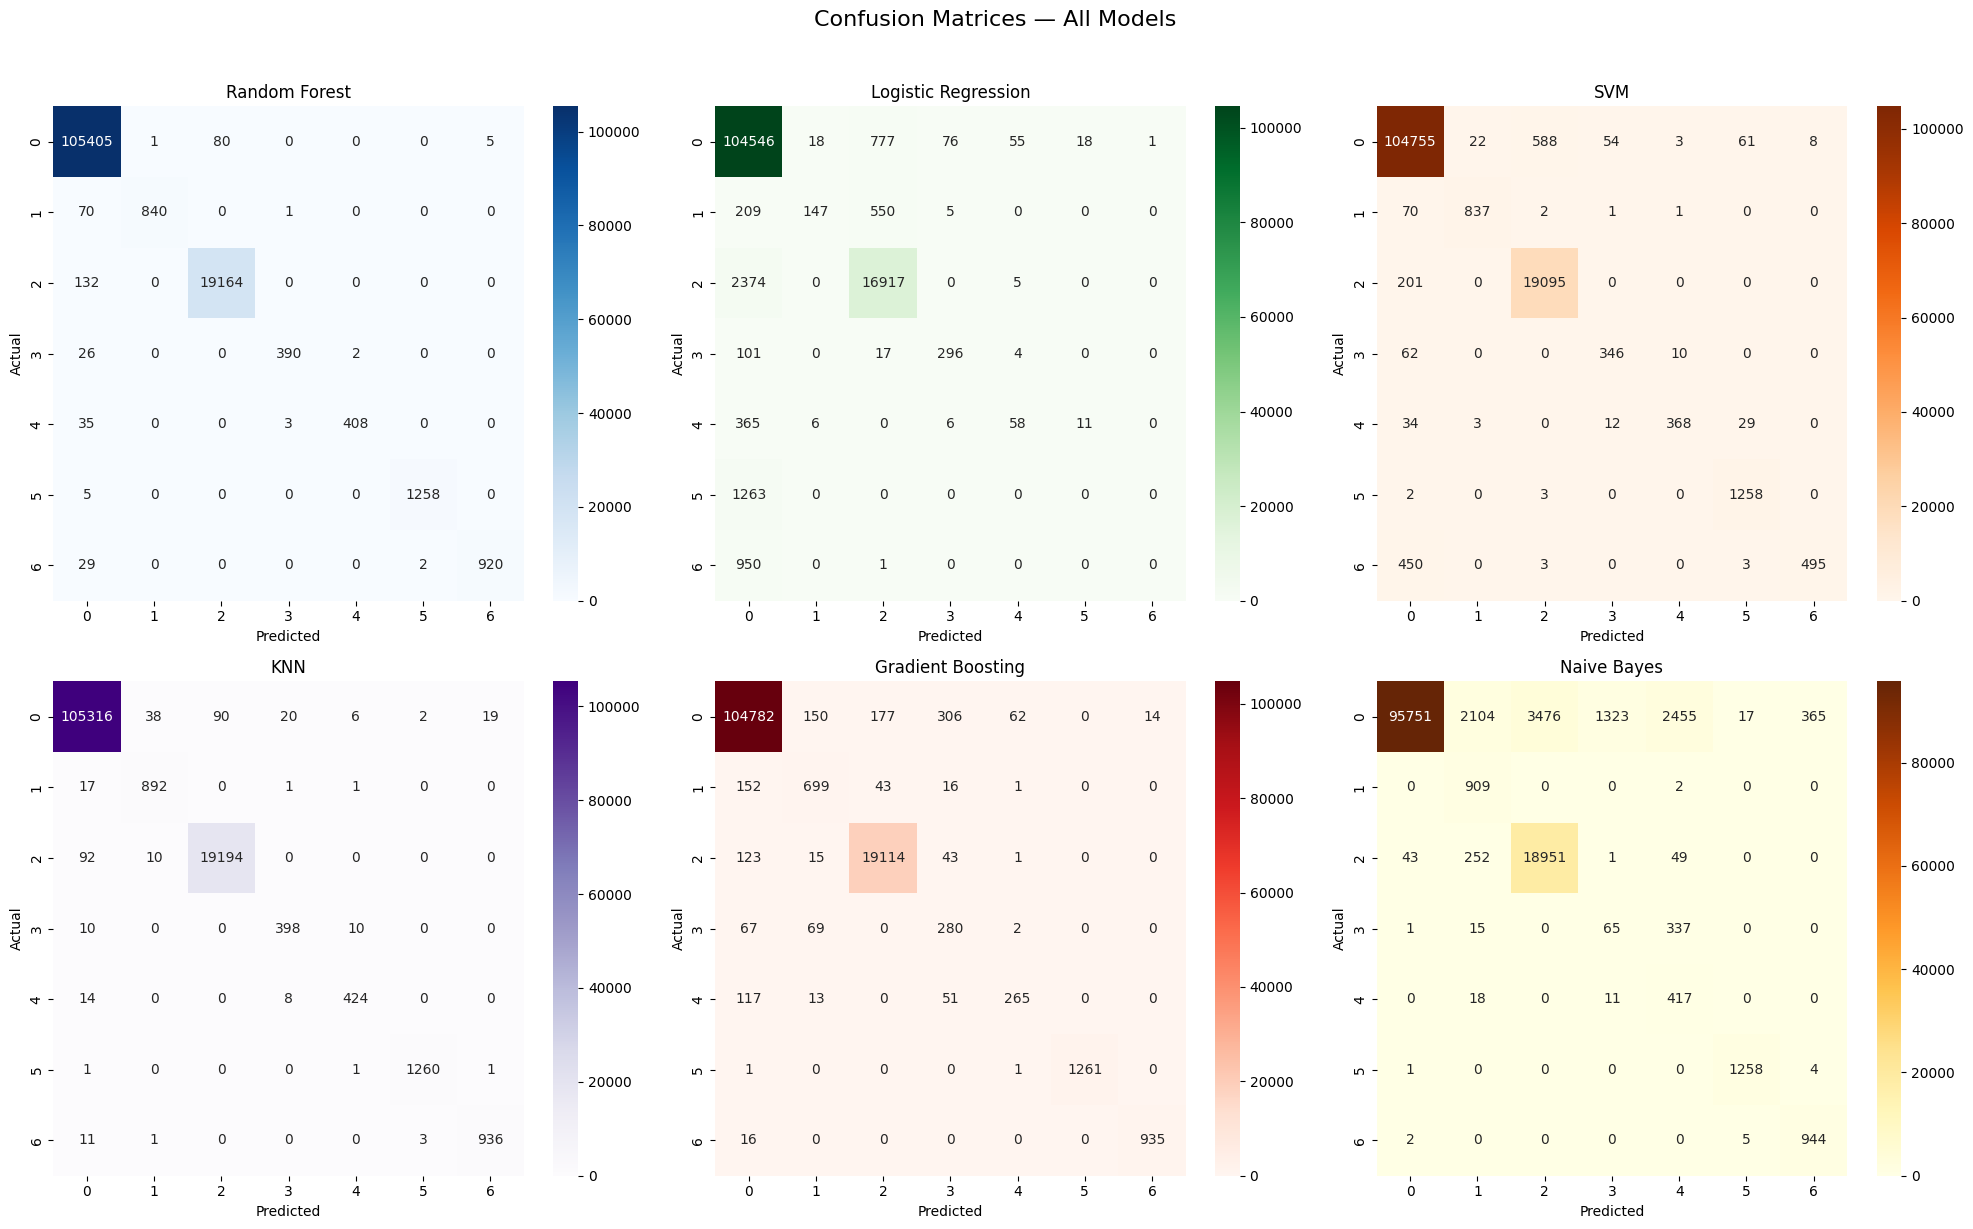

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12)) # all the matrices in one single chart

models = [
    ('Random Forest', pred_rf, 'Blues'),
    ('Logistic Regression', pred_lr, 'Greens'),
    ('SVM', pred_svm, 'Oranges'),
    ('KNN', pred_knn, 'Purples'),
    ('Gradient Boosting', pred_gb, 'Reds'),
    ('Naive Bayes', pred_nb, 'YlOrBr')
]

for ax, (name, preds, cmap) in zip(axes.flatten(), models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrices — All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 5.3. Model Comparison Summary

              Model  Weighted F1
                KNN     0.997241
      Random Forest     0.996941
  Gradient Boosting     0.989243
       SVM (Linear)     0.986854
Logistic Regression     0.935578
        Naive Bayes     0.935400


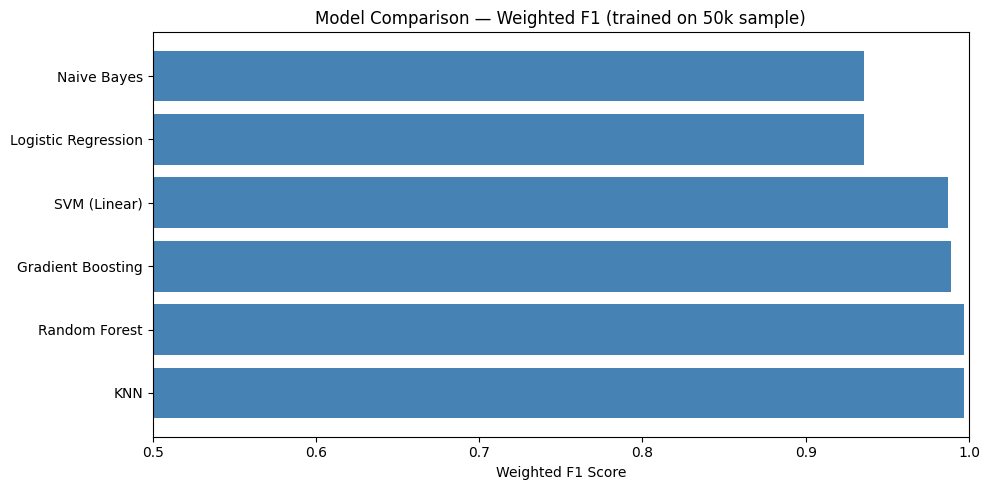

In [26]:
summary = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'SVM (Linear)',
              'KNN', 'Gradient Boosting', 'Naive Bayes'],
    'Weighted F1': [f1_rf, f1_lr, f1_svm, f1_knn, f1_gb, f1_nb]
}).sort_values('Weighted F1', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False)) # values wil be considered to select best model

plt.figure(figsize=(10, 5))
plt.barh(summary['Model'], summary['Weighted F1'], color='steelblue')
plt.xlim(0.5, 1.0)
plt.xlabel('Weighted F1 Score')
plt.title('Model Comparison — Weighted F1 (trained on 50k sample)')
plt.tight_layout()
plt.show()

# SECTION VI:

## 6. ROC Curves

### 6.1. ROC Curve (Multiclass)

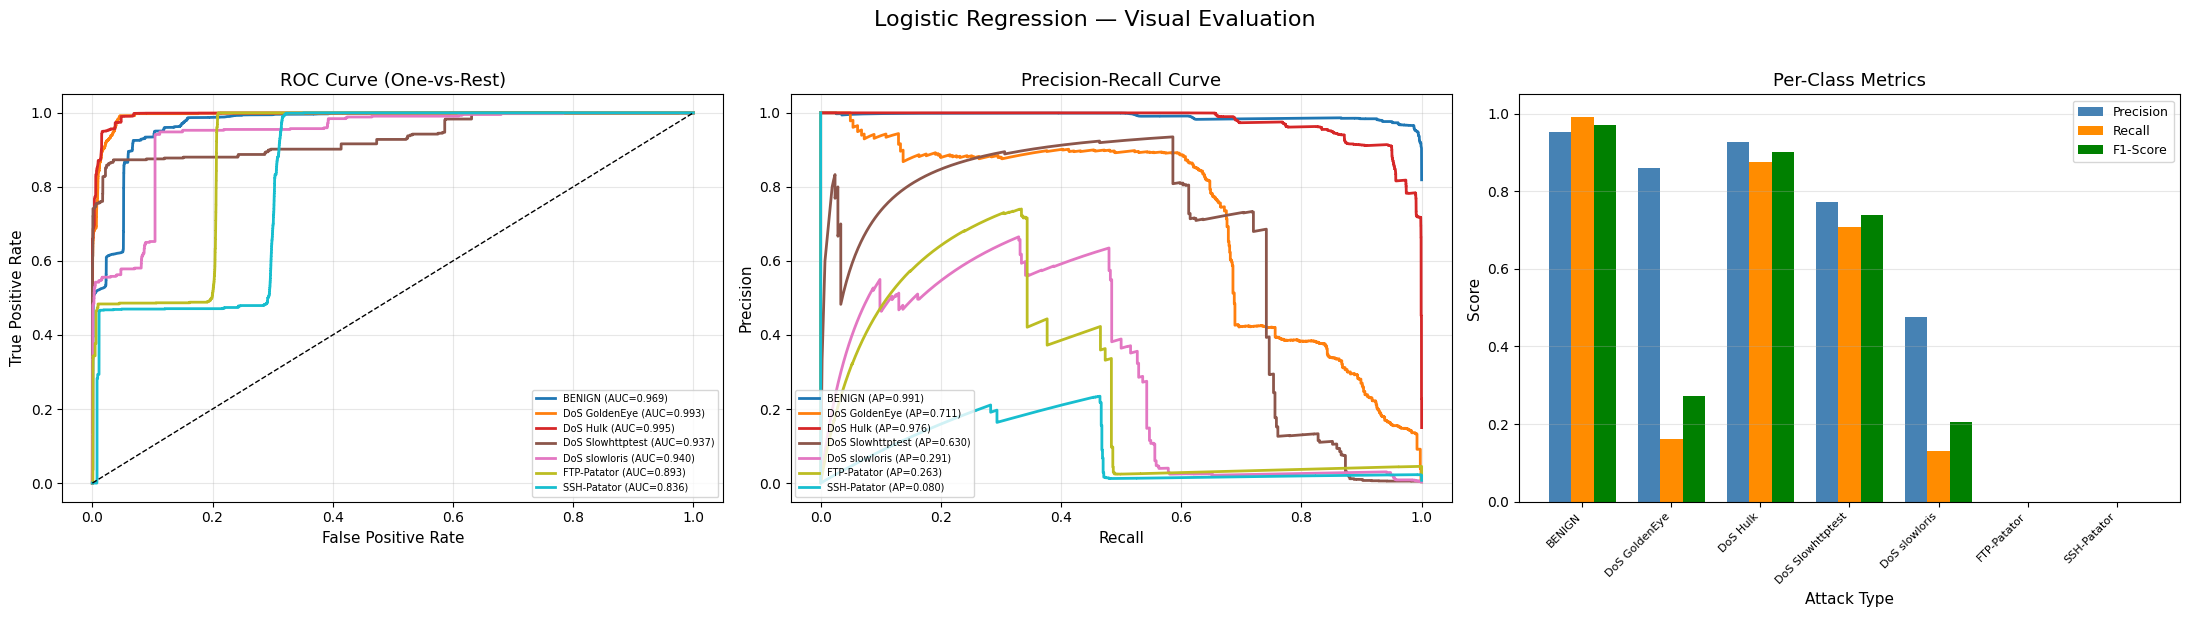

In [27]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get all unique class labels and their real names
classes = np.unique(y_test)
n_classes = len(classes)
label_names = le.inverse_transform(classes)  # real attack names

# Convert y_test to binary matrix for OvR evaluation
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities for each class
y_score = lr.predict_proba(X_test_scaled)

# Color palette
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

# Create 1 row x 3 columns layout
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# ---- Plot 1: ROC Curve ----
for i, name in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC={roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve (One-vs-Rest)', fontsize=13)
ax1.legend(fontsize=7, loc='lower right')
ax1.grid(True, alpha=0.3)

# ---- Plot 2: Precision-Recall Curve ----
for i, name in enumerate(label_names):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    ax2.plot(rec, prec, color=colors[i], lw=2, label=f'{name} (AP={ap:.3f})')

ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curve', fontsize=13)
ax2.legend(fontsize=7, loc='lower left')
ax2.grid(True, alpha=0.3)

# ---- Plot 3: Per-Class Bar Chart ----
report = classification_report(y_test, pred_lr, output_dict=True)
precision_vals = [report[str(c)]['precision'] for c in classes]
recall_vals = [report[str(c)]['recall'] for c in classes]
f1_vals = [report[str(c)]['f1-score'] for c in classes]

x = np.arange(n_classes)
width = 0.25

ax3.bar(x - width, precision_vals, width, label='Precision', color='steelblue')
ax3.bar(x, recall_vals, width, label='Recall', color='darkorange')
ax3.bar(x + width, f1_vals, width, label='F1-Score', color='green')

ax3.set_xlabel('Attack Type', fontsize=11)
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Per-Class Metrics', fontsize=13)
ax3.set_xticks(x)
ax3.set_xticklabels(label_names, rotation=45, ha='right', fontsize=8)  # rotated for readability
ax3.set_ylim(0, 1.05)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# Main title
fig.suptitle('Logistic Regression — Visual Evaluation', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 6.2. Conclusion


This study evaluated six machine learning models for classifying network intrusion attacks using the CICIDS2017 dataset. The models were compared based on their weighted F1 scores, and the results are summarized below:

| Model               | Weighted F1 |
|---------------------|-------------|
| KNN                 | 0.9972      |
| Random Forest       | 0.9969      |
| Gradient Boosting   | 0.9892      |
| SVM (Linear)        | 0.9869      |
| Logistic Regression | 0.9356      |
| Naive Bayes         | 0.9354      |

**KNN** achieved the highest weighted F1 score (0.9972), making it the best-performing model in this experiment. This strong performance can be attributed to the nature of network traffic data: similar attack types (e.g., DoS Hulk, DoS GoldenEye) generate similar patterns in features such as packet lengths, flow durations, and byte rates. KNN capitalizes on this by classifying new samples based on proximity to known examples in feature space, which aligns naturally with how network attacks cluster together.

**Random Forest** performed nearly as well (0.9969) due to its ability to capture non-linear relationships between features through ensemble decision trees. Each tree learns different splitting rules on features like flow IAT, packet sizes, and flag counts, making it highly effective at distinguishing between attack categories.

**Gradient Boosting** and **SVM (Linear)** also performed well (above 0.98), though SVM's linear kernel limits its ability to model complex decision boundaries between overlapping attack classes.

**Logistic Regression** and **Naive Bayes** ranked lowest (~0.93). Logistic Regression assumes linear separability between classes, which does not hold for network traffic data where attack types share overlapping feature ranges. Naive Bayes further suffers from its assumption that all features are independent, which is violated in this dataset where features like forward and backward packet lengths are naturally correlated.

The class-level analysis revealed that all models struggled most with minority classes such as **DoS Slowhttptest**, **DoS slowloris**, and **Heartbleed**, which had significantly fewer samples compared to **BENIGN** (105,491 samples) and **DoS Hulk** (19,296 samples). This class imbalance led to lower precision and recall for these attack types, particularly in simpler models.

**Final recommendation:** While KNN achieved the highest accuracy, **Random Forest** is the more practical choice for real-world deployment in an intrusion detection system. KNN requires storing the entire training set and comparing each new sample against all stored examples, making it slow at prediction time. Random Forest, on the other hand, offers nearly identical performance with significantly faster inference, making it more suitable for real-time network monitoring.

# PART II - TEST DATASET

## Train best model (KNN) and predict on test set

In [32]:

import pandas as pd

# 1. Load the unseen blind test dataset
blind_test_df = pd.read_csv("Cyber_Attack_Detection_test_features.csv")

# 2. Fix hidden whitespace issues in column names (crucial for this dataset)
blind_test_df.columns = blind_test_df.columns.str.strip()

# 3. Drop the redundant columns
cols_to_drop = [
    "Fwd Header Length.1", "Bwd PSH Flags", "Fwd URG Flags", "Bwd URG Flags", 
    "CWE Flag Count", "Fwd Avg Bytes/Bulk", "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk", "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate",
    "Subflow Fwd Packets", "Subflow Bwd Packets", "Subflow Fwd Bytes", "Subflow Bwd Bytes",
    "Flow IAT Min", "Fwd IAT Min", "Init_Win_bytes_forward", "Init_Win_bytes_backward"
]
blind_test_df = blind_test_df.drop(columns=[c for c in cols_to_drop if c in blind_test_df.columns])

# 4. Safely select only the correct numeric columns 
# (Filters out the columns we just dropped to prevent the KeyError)
final_numeric_features = [col for col in numeric_cols if col in blind_test_df.columns]
X_blind = blind_test_df[final_numeric_features]

# 5. Fill any missing values with the median 
X_blind_imputed = X_blind.fillna(X_blind.median())

# 6. Scale the unseen data using the scaler you fitted earlier
X_blind_scaled = scaler.transform(X_blind_imputed)

# 7. Generate predictions using the trained KNN model
y_hat = knn.predict(X_blind_scaled)

# 8. Convert numeric predictions back to original attack names
y_hat_labels = le.inverse_transform(y_hat)

# 9. Display a few sample predictions
print(f"Predictions generated: {len(y_hat_labels)} samples\n")
print("Sample predictions (first 10):")
for i in range(10):
    print(f"  Predicted: {y_hat_labels[i]}")

# 10. Export to CSV for submission
results_df = pd.DataFrame({'Predicted_Label': y_hat_labels})
results_df.to_csv('test_predictions.csv', index=False)
print(f"\nSuccessfully generated blind test predictions. CSV saved as 'test_predictions.csv'.")

Predictions generated: 107434 samples

Sample predictions (first 10):
  Predicted: DoS Hulk
  Predicted: DoS Slowhttptest
  Predicted: BENIGN
  Predicted: BENIGN
  Predicted: DoS Hulk
  Predicted: BENIGN
  Predicted: DoS Hulk
  Predicted: BENIGN
  Predicted: BENIGN
  Predicted: DoS Hulk

Successfully generated blind test predictions. CSV saved as 'test_predictions.csv'.


In [33]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the true labels from the file you just uploaded
# (Make sure the file is in the same folder as your notebook)
true_labels_df = pd.read_csv("Cyber_Attack_Detection_test_labels.csv")

# Extract the actual labels (assuming the column is named 'Label')
y_actual = true_labels_df['Label']

# 2. Load the predictions you generated and saved in the previous step
predictions_df = pd.read_csv("test_predictions.csv")
y_predicted = predictions_df['Predicted_Label']

# 3. Calculate and print the overall accuracy
acc = accuracy_score(y_actual, y_predicted)
print(f"Final Blind Test Accuracy: {acc * 100:.4f}%\n")

# 4. Print the detailed classification report
print("Detailed Classification Report:")
print(classification_report(y_actual, y_predicted))

Final Blind Test Accuracy: 99.6751%

Detailed Classification Report:


c:\Users\kakum\OneDrive\Desktop\apdi\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     88157
   DoS GoldenEye       0.95      0.97      0.96       703
        DoS Hulk       0.99      0.99      0.99     15947
DoS Slowhttptest       0.94      0.94      0.94       373
   DoS slowloris       0.93      0.95      0.94       399
     FTP-Patator       0.99      1.00      1.00      1064
      Heartbleed       0.00      0.00      0.00         1
     SSH-Patator       0.99      0.99      0.99       790

        accuracy                           1.00    107434
       macro avg       0.85      0.85      0.85    107434
    weighted avg       1.00      1.00      1.00    107434



c:\Users\kakum\OneDrive\Desktop\apdi\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kakum\OneDrive\Desktop\apdi\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
